In [24]:
import pandas as pd
df = pd.read_csv('/Exercício Logística.csv')

# Remover idades negativas ou irreais (ex: menor que 14 anos ou maior que 100)
# Aqui vamos focar no erro óbvio: valores negativos.
df = df[df['idade'] >= 18]

# Remover salários negativos
df = df[df['salario'] >= 0]

# (Opcional) Verificar se existem valores nulos (NaN) e removê-los
df = df.dropna()

print(f"Dataset limpo! Linhas restantes: {len(df)}")
print(df.describe()) # Confira se o 'min' de idade e salario agora é >= 0

Dataset limpo! Linhas restantes: 235
           idade  tempo_emprego       salario       dividas  \
count  235.00000     235.000000    235.000000    235.000000   
mean    31.72766       3.781702   4914.144681   7856.992723   
std      8.24895       2.618272   2804.520692   5994.346038   
min     18.00000       0.000000     16.000000     46.990000   
25%     26.00000       1.500000   2554.500000   3030.285000   
50%     31.00000       3.600000   4899.000000   6845.180000   
75%     36.00000       5.450000   6956.500000  11189.410000   
max     65.00000      13.500000  11659.000000  33516.110000   

       pontuacao_credito  qtde_compras_online  inadimplente  
count         235.000000           235.000000    235.000000  
mean          151.625532             9.182979      0.353191  
std           107.846620             6.673436      0.478982  
min             1.000000             0.000000      0.000000  
25%            69.500000             4.000000      0.000000  
50%           135.00000

In [25]:
df['inadimplente'].value_counts()

,count
inadimplente,
0,152
1,83


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Ajuste os nomes das colunas conforme seu CSV.
# Geralmente o alvo é a última ou se chama 'Inadimplente'
X = df.drop(columns=['inadimplente']) # Substitua pelo nome real da coluna alvo
y = df['inadimplente']

# 2. Holdout (50% treino, 50% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Padronização (Essencial para Regressão Logística, especialmente com solvers como 'saga')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Balanceamento com SMOTE (Apenas no Treino!)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Dados balanceados: {y_resampled.value_counts()}")

# 5. Testando diferentes Solvers
solvers = ['lbfgs', 'liblinear', 'newton-cg', 'saga']
resultados = {}

for s in solvers:
    model = LogisticRegression(solver=s, max_iter=10000)
    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    resultados[s] = acc
    print(f"Solver: {s} | Acurácia: {acc:.4f}")

# 6. Escolher o melhor e treinar o modelo final
melhor_solver = max(resultados, key=resultados.get)
print(f"\n🏆 O melhor solver foi: {melhor_solver}")

modelo_final = LogisticRegression(solver=melhor_solver, max_iter=10000)
modelo_final.fit(X_resampled, y_resampled)

# Avaliação final detalhada
y_pred_final = modelo_final.predict(X_test_scaled)
print("\nRelatório de Classificação Final:")
print(classification_report(y_test, y_pred_final))

Dados balanceados: inadimplente
0    103
1    103
Name: count, dtype: int64
Solver: lbfgs | Acurácia: 0.7887
Solver: liblinear | Acurácia: 0.7887
Solver: newton-cg | Acurácia: 0.7887
Solver: saga | Acurácia: 0.7887

🏆 O melhor solver foi: lbfgs

Relatório de Classificação Final:
              precision    recall  f1-score   support

           0       0.97      0.71      0.82        49
           1       0.60      0.95      0.74        22

    accuracy                           0.79        71
   macro avg       0.79      0.83      0.78        71
weighted avg       0.86      0.79      0.80        71



=== Distribuição original da variável alvo ===
inadimplente
0    152
1     83
Name: count, dtype: int64

Shape: (235, 7)

=== Holdout ===
Treino : 117 amostras
Teste  : 118 amostras

=== Após SMOTE (treino) ===
inadimplente
0    76
1    76
Name: count, dtype: int64

=== Comparação de Solvers ===
Solver           Acurácia Treino  Acurácia Teste
------------------------------------------------
lbfgs                     0.8750          0.8559
liblinear                 0.8750          0.8475
saga                      0.8750          0.8559
newton-cg                 0.8750          0.8559
sag                       0.8750          0.8559


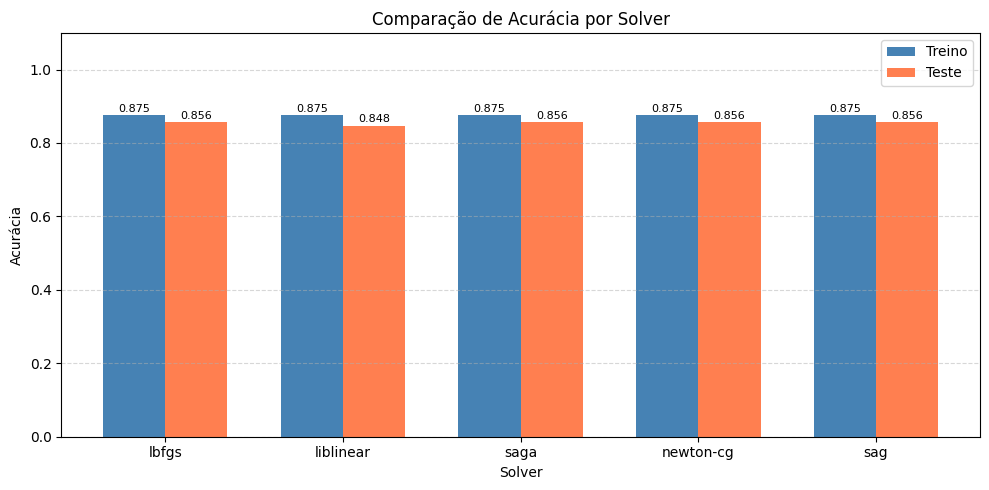


Gráfico salvo: comparacao_solvers.png

=== Melhor Solver: lbfgs (Acurácia Teste = 0.8559) ===

=== Relatório de Classificação (Modelo Final) ===
              precision    recall  f1-score   support

  Adimplente       0.94      0.83      0.88        76
Inadimplente       0.75      0.90      0.82        42

    accuracy                           0.86       118
   macro avg       0.84      0.87      0.85       118
weighted avg       0.87      0.86      0.86       118



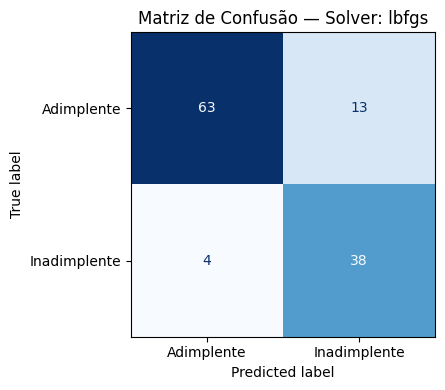

Matriz de confusão salva: matriz_confusao.png


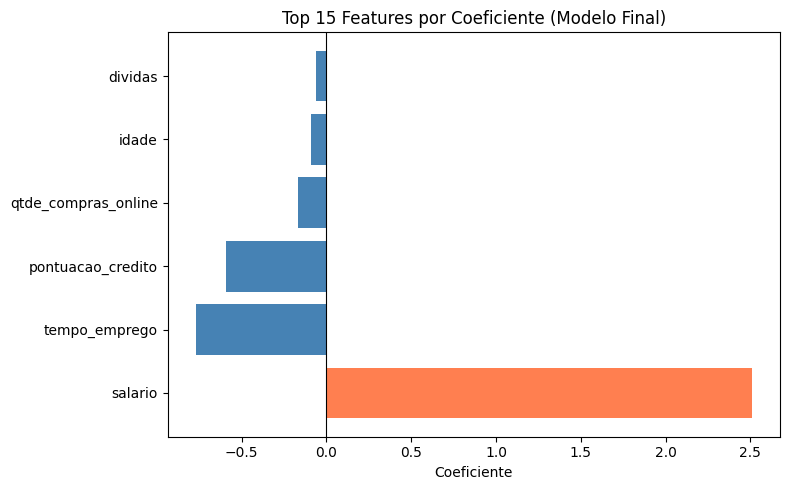

Importância das features salva: importancia_features.png


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from imblearn.over_sampling import SMOTE

# ============================================================
# 1. CARREGAMENTO DOS DADOS
# ============================================================
# AJUSTE: troque pelo caminho/nome do seu arquivo e coluna alvo
TARGET_COL = "inadimplente"                   # <-- ajuste aqui: 1=inadimplente, 0=nao

print("=== Distribuição original da variável alvo ===")
print(df[TARGET_COL].value_counts())
print(f"\nShape: {df.shape}")

# ============================================================
# 2. PRÉ-PROCESSAMENTO
# ============================================================
# Separar features e alvo
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Codificar variáveis categóricas (se houver)
X = pd.get_dummies(X, drop_first=True)

# Normalização (StandardScaler)
scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# ============================================================
# 3. HOLDOUT — DIVISÃO TREINO / TESTE (70/30)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.50,
    random_state=42,
    stratify=y       # mantém proporção das classes no split
)

print(f"\n=== Holdout ===")
print(f"Treino : {X_train.shape[0]} amostras")
print(f"Teste  : {X_test.shape[0]} amostras")

# ============================================================
# 4. BALANCEAMENTO COM SMOTE (apenas no treino!)
# ============================================================
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"\n=== Após SMOTE (treino) ===")
print(pd.Series(y_train_bal).value_counts())

# ============================================================
# 5. COMPARAÇÃO DE SOLVERS
# ============================================================
solvers = ['lbfgs', 'liblinear', 'saga', 'newton-cg', 'sag']
resultados = []

print("\n=== Comparação de Solvers ===")
print(f"{'Solver':<15} {'Acurácia Treino':>16} {'Acurácia Teste':>15}")
print("-" * 48)

for solver in solvers:
    try:
        modelo = LogisticRegression(
            solver=solver,
            max_iter=1000,
            random_state=42
        )
        modelo.fit(X_train_bal, y_train_bal)

        acc_treino = accuracy_score(y_train_bal, modelo.predict(X_train_bal))
        acc_teste  = accuracy_score(y_test,      modelo.predict(X_test))

        resultados.append({
            'Solver'          : solver,
            'Acurácia Treino' : round(acc_treino, 4),
            'Acurácia Teste'  : round(acc_teste,  4)
        })
        print(f"{solver:<15} {acc_treino:>16.4f} {acc_teste:>15.4f}")

    except Exception as e:
        print(f"{solver:<15} ERRO: {e}")

df_resultados = pd.DataFrame(resultados)

# ============================================================
# 6. VISUALIZAÇÃO — ACURÁCIA POR SOLVER
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_resultados))
width = 0.35

ax.bar(x - width/2, df_resultados['Acurácia Treino'], width, label='Treino',  color='steelblue')
ax.bar(x + width/2, df_resultados['Acurácia Teste'],  width, label='Teste',   color='coral')

ax.set_xlabel('Solver')
ax.set_ylabel('Acurácia')
ax.set_title('Comparação de Acurácia por Solver')
ax.set_xticks(x)
ax.set_xticklabels(df_resultados['Solver'])
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

for i, row in df_resultados.iterrows():
    ax.text(i - width/2, row['Acurácia Treino'] + 0.01, f"{row['Acurácia Treino']:.3f}", ha='center', fontsize=8)
    ax.text(i + width/2, row['Acurácia Teste']  + 0.01, f"{row['Acurácia Teste']:.3f}",  ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("comparacao_solvers.png", dpi=150)
plt.show()
print("\nGráfico salvo: comparacao_solvers.png")

# ============================================================
# 7. TREINO DO MELHOR MODELO
# ============================================================
melhor = df_resultados.loc[df_resultados['Acurácia Teste'].idxmax()]
melhor_solver = melhor['Solver']
print(f"\n=== Melhor Solver: {melhor_solver} "
      f"(Acurácia Teste = {melhor['Acurácia Teste']:.4f}) ===")

modelo_final = LogisticRegression(
    solver=melhor_solver,
    max_iter=1000,
    random_state=42
)
modelo_final.fit(X_train_bal, y_train_bal)

# ============================================================
# 8. AVALIAÇÃO FINAL
# ============================================================
y_pred = modelo_final.predict(X_test)

print("\n=== Relatório de Classificação (Modelo Final) ===")
print(classification_report(y_test, y_pred,
                             target_names=['Adimplente', 'Inadimplente']))

# Matriz de Confusão
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Adimplente', 'Inadimplente'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusão — Solver: {melhor_solver}')
plt.tight_layout()
plt.savefig("matriz_confusao.png", dpi=150)
plt.show()
print("Matriz de confusão salva: matriz_confusao.png")

# ============================================================
# 9. IMPORTÂNCIA DAS FEATURES (coeficientes)
# ============================================================
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coeficiente': modelo_final.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
cores = ['coral' if c > 0 else 'steelblue' for c in coef_df['Coeficiente']]
ax.barh(coef_df['Feature'], coef_df['Coeficiente'], color=cores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 Features por Coeficiente (Modelo Final)')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.savefig("importancia_features.png", dpi=150)
plt.show()
print("Importância das features salva: importancia_features.png")

In [28]:
df.describe()

,idade,tempo_emprego,salario,dividas,pontuacao_credito,qtde_compras_online,inadimplente
count,235.00000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000
mean,31.72766,3.781702,4914.144681,7856.992723,151.625532,9.182979,0.353191
std,8.24895,2.618272,2804.520692,5994.346038,107.846620,6.673436,0.478982
min,18.00000,0.000000,16.000000,46.990000,1.000000,0.000000,0.000000
25%,26.00000,1.500000,2554.500000,3030.285000,69.500000,4.000000,0.000000
50%,31.00000,3.600000,4899.000000,6845.180000,135.000000,7.000000,0.000000
75%,36.00000,5.450000,6956.500000,11189.410000,224.000000,13.000000,1.000000
max,65.00000,13.500000,11659.000000,33516.110000,578.000000,33.000000,1.000000


In [29]:
df['inadimplente'].value_counts()

,count
inadimplente,
0,152
1,83
